In [1]:
import pandas as pd
df1 = pd.read_csv("anti_inflam.csv")
df2 = pd.read_csv("anti_oxidant.csv")
df3 = pd.read_csv("stroke.csv")

In [2]:
pct1 = df1.eq(1).mean(numeric_only=True) * 100
pct2 = df2.eq(1).mean(numeric_only=True) * 100
pct3 = df3.eq(1).mean(numeric_only=True) * 100

In [3]:
print(pct1)
print(pct2)
print(pct3)

cid        0.000000
SMILES     0.000000
stat      10.455403
mtor      64.510914
nfkb      32.821342
dtype: float64
cid        0.000000
SMILES     0.000000
AO        20.023170
ROS       29.774088
NRF2      50.106198
dtype: float64
cid        0.000000
SMILES     0.000000
value     42.351109
dtype: float64


In [4]:
merged_df = pd.concat([df1.iloc[:, :2],df2.iloc[:, :2],  df3.iloc[:, :2]], ignore_index=True)

In [5]:
dft = pd.read_csv("newtest.csv")

In [6]:
df_dedup = merged_df.drop_duplicates(subset="cid", keep="first").reset_index(drop=True)

In [7]:
merged_df = df_dedup

In [8]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import pandas as pd
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    else:
        return None
fps_merged = [smiles_to_fp(s) for s in merged_df["SMILES"]]
fps_dft = [smiles_to_fp(s) for s in dft["SMILES"]]
sim_matrix = []
for fp2 in fps_dft:
    sims = [DataStructs.TanimotoSimilarity(fp2, fp1) if (fp2 is not None and fp1 is not None) else None
            for fp1 in fps_merged]
    sim_matrix.append(sims)
sim_df = pd.DataFrame(sim_matrix, index=dft["Compound_CID"], columns=merged_df["cid"]).astype(float)

[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not removing hydrogen atom without neighbors
[21:29:53] WARNING: not r

In [9]:
matches_equal_1 = (sim_df == 1.0)
equal_1_pairs = [
    (row_idx, col_idx)
    for row_idx, row in matches_equal_1.iterrows()
    for col_idx, val in row.items()
    if val
]
equal_1_df = pd.DataFrame(equal_1_pairs, columns=["query_cid", "target_cid"])
print(equal_1_df)

Empty DataFrame
Columns: [query_cid, target_cid]
Index: []


In [10]:
######################################################
import pandas as pd
dft2 = pd.read_csv("training2.csv").iloc[:, :2]

In [11]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import pandas as pd

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    else:
        return None
fps_merged = [smiles_to_fp(s) for s in dft2["SMILES"]]
fps_df2 = [smiles_to_fp(s) for s in dft["SMILES"]]
sim_matrix = []
for fp2 in fps_df2:
    sims = [DataStructs.TanimotoSimilarity(fp2, fp1) if fp2 and fp1 else None
            for fp1 in fps_merged]
    sim_matrix.append(sims)
sim_df2 = pd.DataFrame(sim_matrix, index=dft["Compound_CID"], columns=dft2["ID"])

In [12]:
merged = pd.concat([sim_df, sim_df2], axis=1, sort=False)

In [13]:
sim_df

cid,1150,1697,1858,2157,2284,2708,2781,2993,3191,3220,...,135546791,135547284,135735434,135829845,135871452,135871453,135894587,135896301,136153084,136153085
Compound_CID,,,,,,,,,,,,,,,,,,,,,
44129648,0.081081,0.081081,0.129412,0.125000,0.123288,0.146667,0.170732,0.103896,0.181818,0.125000,...,0.144330,0.134831,0.142857,0.146067,0.175258,0.202381,0.131868,0.132653,0.185567,0.180851
644019,0.081967,0.047619,0.123288,0.132530,0.062500,0.125000,0.093333,0.109375,0.111111,0.135593,...,0.154762,0.115385,0.111111,0.128205,0.123596,0.115385,0.112500,0.114943,0.122222,0.127907
6440940,0.017241,0.053571,0.086957,0.074074,0.089286,0.101695,0.102941,0.049180,0.121622,0.090909,...,0.071429,0.066667,0.121622,0.080000,0.120482,0.142857,0.078947,0.111111,0.105882,0.111111
11430856,0.065789,0.125000,0.141176,0.112245,0.092105,0.115385,0.154762,0.102564,0.220930,0.093333,...,0.154639,0.096774,0.153846,0.095745,0.138614,0.146067,0.118280,0.131313,0.160000,0.154639
154731077,0.180000,0.102804,0.165217,0.106061,0.090909,0.078261,0.116667,0.078947,0.183333,0.062500,...,0.103704,0.085938,0.118110,0.076923,0.225806,0.139344,0.101562,0.095588,0.125000,0.128788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.105263,0.000000,0.035714,0.044776,0.100000,0.090909,0.017544,0.068182,0.047619,0.023810,...,0.057971,0.067797,0.064516,0.066667,0.055556,0.050000,0.048387,0.028169,0.040541,0.042857
68617,0.092593,0.156863,0.119403,0.101266,0.089286,0.065574,0.171875,0.122807,0.121622,0.071429,...,0.125000,0.081081,0.106667,0.080000,0.134146,0.159420,0.078947,0.084337,0.146341,0.125000
892,0.000000,0.000000,0.022222,0.017544,0.032258,0.028571,0.022222,0.000000,0.038462,0.033333,...,0.033898,0.020000,0.018868,0.019608,0.032258,0.040816,0.019231,0.016667,0.031746,0.033898


In [14]:
sim_df2

ID,BRD-A00147595,BRD-A00218260,BRD-A00376169,BRD-A00546892,BRD-A00938334,BRD-A01636364,BRD-A01645196,BRD-A01787639,BRD-A02006392,BRD-A02367930,...,BRD-K57222227,BRD-K57371763,BRD-K57432881,BRD-K57545991,BRD-K57569181,BRD-K57631554,BRD-K57764956,BRD-K58010567,BRD-K58114536,BRD-K58211978
Compound_CID,,,,,,,,,,,,,,,,,,,,,
44129648,0.163043,0.083333,0.101266,0.130952,0.105263,0.230769,0.111111,0.136364,0.162791,0.101124,...,0.204819,0.086667,0.141176,0.220930,0.094118,0.075758,0.179775,0.145631,0.103896,0.074627
644019,0.081395,0.026667,0.089552,0.080000,0.083333,0.188406,0.139785,0.075000,0.116883,0.150685,...,0.088608,0.079710,0.092105,0.166667,0.097222,0.036364,0.109756,0.106383,0.145161,0.065574
6440940,0.075000,0.029412,0.118644,0.072464,0.105263,0.136364,0.112360,0.053333,0.097222,0.115942,...,0.097222,0.067669,0.070423,0.150685,0.090909,0.086957,0.105263,0.077778,0.103448,0.078947
11430856,0.125000,0.057471,0.100000,0.185185,0.081633,0.276316,0.100000,0.188235,0.160920,0.112360,...,0.109890,0.100671,0.152941,0.177778,0.146341,0.058824,0.292683,0.252632,0.131579,0.074074
154731077,0.124031,0.057377,0.086957,0.117647,0.100000,0.116667,0.120567,0.121951,0.140496,0.105691,...,0.086614,0.098361,0.106557,0.144000,0.065041,0.058252,0.108527,0.122302,0.098214,0.089820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.045455,0.019231,0.020833,0.036364,0.000000,0.054545,0.025000,0.033333,0.050847,0.016949,...,0.050847,0.016260,0.035088,0.030769,0.078431,0.137931,0.030769,0.066667,0.021739,0.039216
68617,0.102564,0.076923,0.137931,0.104478,0.076923,0.136364,0.076087,0.112676,0.128571,0.149254,...,0.097222,0.067669,0.085714,0.135135,0.043478,0.000000,0.166667,0.054348,0.254902,0.033613
892,0.036364,0.000000,0.121212,0.046512,0.018519,0.045455,0.044776,0.020408,0.041667,0.043478,...,0.020408,0.036697,0.021739,0.037736,0.023810,0.050000,0.037736,0.014925,0.029412,0.044444


In [15]:
merged

,1150,1697,1858,2157,2284,2708,2781,2993,3191,3220,...,BRD-K57222227,BRD-K57371763,BRD-K57432881,BRD-K57545991,BRD-K57569181,BRD-K57631554,BRD-K57764956,BRD-K58010567,BRD-K58114536,BRD-K58211978
Compound_CID,,,,,,,,,,,,,,,,,,,,,
44129648,0.081081,0.081081,0.129412,0.125000,0.123288,0.146667,0.170732,0.103896,0.181818,0.125000,...,0.204819,0.086667,0.141176,0.220930,0.094118,0.075758,0.179775,0.145631,0.103896,0.074627
644019,0.081967,0.047619,0.123288,0.132530,0.062500,0.125000,0.093333,0.109375,0.111111,0.135593,...,0.088608,0.079710,0.092105,0.166667,0.097222,0.036364,0.109756,0.106383,0.145161,0.065574
6440940,0.017241,0.053571,0.086957,0.074074,0.089286,0.101695,0.102941,0.049180,0.121622,0.090909,...,0.097222,0.067669,0.070423,0.150685,0.090909,0.086957,0.105263,0.077778,0.103448,0.078947
11430856,0.065789,0.125000,0.141176,0.112245,0.092105,0.115385,0.154762,0.102564,0.220930,0.093333,...,0.109890,0.100671,0.152941,0.177778,0.146341,0.058824,0.292683,0.252632,0.131579,0.074074
154731077,0.180000,0.102804,0.165217,0.106061,0.090909,0.078261,0.116667,0.078947,0.183333,0.062500,...,0.086614,0.098361,0.106557,0.144000,0.065041,0.058252,0.108527,0.122302,0.098214,0.089820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.105263,0.000000,0.035714,0.044776,0.100000,0.090909,0.017544,0.068182,0.047619,0.023810,...,0.050847,0.016260,0.035088,0.030769,0.078431,0.137931,0.030769,0.066667,0.021739,0.039216
68617,0.092593,0.156863,0.119403,0.101266,0.089286,0.065574,0.171875,0.122807,0.121622,0.071429,...,0.097222,0.067669,0.085714,0.135135,0.043478,0.000000,0.166667,0.054348,0.254902,0.033613
892,0.000000,0.000000,0.022222,0.017544,0.032258,0.028571,0.022222,0.000000,0.038462,0.033333,...,0.020408,0.036697,0.021739,0.037736,0.023810,0.050000,0.037736,0.014925,0.029412,0.044444


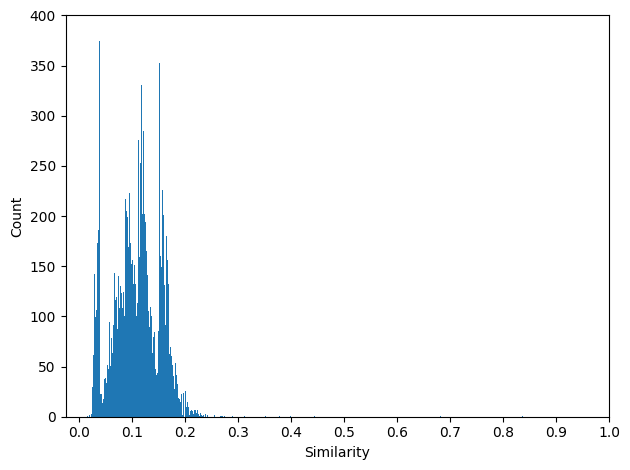

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = None
for name in ["merged", "sim_df", "sim_df2"]:
    if name in globals():
        df = globals()[name]
        break

row_key = 644019
if row_key not in df.index and str(row_key) in df.index:
    row_key = str(row_key)
s = pd.to_numeric(df.loc[row_key], errors="coerce").dropna().astype(float)
plt.figure()
plt.hist(s.values, bins=500)   
plt.xlabel("Similarity")
plt.ylabel("Count")
plt.ylim(0, 400)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.tight_layout()
plt.savefig(
    f"hist_{row_key}_600dpi.jpg",
    format="jpg",
    dpi=1080
)
plt.show()